In [58]:
import Metrica_IO as mio
import Metrica_Viz as mviz
import Metrica_Velocities as mvel
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import importlib
import seaborn as sns

importlib.reload(mvel)

<module 'Metrica_Velocities' from 'd:\\HEC Paris\\M2\\Personal Project\\football-tactical-analysis\\Metrica_Velocities.py'>

In [2]:
DATADIR = "data"
game_id = 2

In [3]:
events = mio.read_event_data(DATADIR, game_id)


In [4]:
# read in tracking data
tracking_home = mio.tracking_data(DATADIR, game_id, "Home")
tracking_away = mio.tracking_data(DATADIR, game_id, "Away")

# Convert positions from metrica units to meters (note change in Metrica's coordinate system since the last lesson)
tracking_home = mio.to_metric_coordinates(tracking_home)
tracking_away = mio.to_metric_coordinates(tracking_away)
events = mio.to_metric_coordinates(events)

# reverse direction of play in the second half so that home team is always attacking from right->left
tracking_home, tracking_away, events = mio.to_single_playing_direction(
    tracking_home, tracking_away, events
)


Reading team: home
Reading team: away


In [15]:
import scipy.signal as signal


def calc_player_velocities(
    team, smoothing=True, filter_="Savitzky-Golay", window=7, polyorder=1, maxspeed=12
):
    """Calculate player velocities in x & y direction, and total player speed at each timestamp of the tracking data"""

    # Remove any existing velocity data
    team = remove_player_velocities(team)

    # Get the player IDs
    player_ids = np.unique([c[:-2] for c in team.columns if c[:4] in ["Home", "Away"]])

    # Calculate time step (dt) and handle NaN values
    dt = team["Time [s]"].diff().fillna(method="bfill")  # Fill first row

    # Iterate through players
    for player in player_ids:
        vx = team[player + "_x"].diff() / dt
        vy = team[player + "_y"].diff() / dt

        # Handle unrealistic speed values (outliers)
        raw_speed = np.sqrt(vx**2 + vy**2)
        vx[raw_speed > maxspeed] = np.nan
        vy[raw_speed > maxspeed] = np.nan

        # Smoothing
        if smoothing:
            try:
                if filter_ == "Savitzky-Golay" and not vx.isna().all():
                    valid_points = vx.dropna().size
                    adjusted_window = min(
                        window,
                        valid_points - 1 if valid_points % 2 == 0 else valid_points,
                    )
                    if adjusted_window >= 3:
                        vx = signal.savgol_filter(
                            vx.fillna(0),
                            window_length=adjusted_window,
                            polyorder=polyorder,
                        )
                        vy = signal.savgol_filter(
                            vy.fillna(0),
                            window_length=adjusted_window,
                            polyorder=polyorder,
                        )
                    else:
                        raise ValueError(
                            "Insufficient valid data points for Savitzky-Golay"
                        )
                elif filter_ == "moving average":
                    vx = vx.rolling(window=window, min_periods=1).mean()
                    vy = vy.rolling(window=window, min_periods=1).mean()
                elif filter_ == "linear interpolation":
                    vx = vx.interpolate(method="linear")
                    vy = vy.interpolate(method="linear")
            except Exception as e:
                print(
                    f"Fallback to linear interpolation for player {player} due to: {e}"
                )
                vx = vx.interpolate(method="linear")
                vy = vy.interpolate(method="linear")

        # Store velocity data in the DataFrame
        team[player + "_vx"] = vx
        team[player + "_vy"] = vy
        team[player + "_speed"] = np.sqrt(vx**2 + vy**2)

    return team


def remove_player_velocities(team):
    """
    Remove existing velocity and acceleration columns from the tracking DataFrame.
    """
    columns_to_remove = [
        c
        for c in team.columns
        if c.split("_")[-1] in ["vx", "vy", "ax", "ay", "speed", "acceleration"]
    ]
    return team.drop(
        columns=columns_to_remove, errors="ignore"
    )  # Ignore if columns are missing

In [16]:
# Check columns in tracking_home and tracking_away
print("Tracking Home Columns:")
print(tracking_home.columns)

print("Tracking Away Columns:")
print(tracking_away.columns)

# Apply velocity calculations separately for home and away teams
tracking_home = calc_player_velocities(tracking_home, smoothing=True)
tracking_away = calc_player_velocities(tracking_away, smoothing=True)


Tracking Home Columns:
Index(['Period', 'Time [s]', 'Home_11_x', 'Home_11_y', 'Home_1_x', 'Home_1_y',
       'Home_2_x', 'Home_2_y', 'Home_3_x', 'Home_3_y', 'Home_4_x', 'Home_4_y',
       'Home_5_x', 'Home_5_y', 'Home_6_x', 'Home_6_y', 'Home_7_x', 'Home_7_y',
       'Home_8_x', 'Home_8_y', 'Home_9_x', 'Home_9_y', 'Home_10_x',
       'Home_10_y', 'Home_12_x', 'Home_12_y', 'Home_13_x', 'Home_13_y',
       'Home_14_x', 'Home_14_y', 'ball_x', 'ball_y', 'Home_1_vx', 'Home_1_vy',
       'Home_1_speed', 'Home_10_vx', 'Home_10_vy', 'Home_10_speed',
       'Home_11_vx', 'Home_11_vy', 'Home_11_speed', 'Home_12_vx', 'Home_12_vy',
       'Home_12_speed', 'Home_13_vx', 'Home_13_vy', 'Home_13_speed',
       'Home_14_vx', 'Home_14_vy', 'Home_14_speed', 'Home_2_vx', 'Home_2_vy',
       'Home_2_speed', 'Home_3_vx', 'Home_3_vy', 'Home_3_speed', 'Home_4_vx',
       'Home_4_vy', 'Home_4_speed', 'Home_5_vx', 'Home_5_vy', 'Home_5_speed',
       'Home_6_vx', 'Home_6_vy', 'Home_6_speed', 'Home_7_vx', 'Home_7_

C:\Users\ameya\AppData\Local\Temp\ipykernel_29644\1067334894.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dt = team["Time [s]"].diff().fillna(method="bfill")  # Fill first row
C:\Users\ameya\AppData\Local\Temp\ipykernel_29644\1067334894.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dt = team["Time [s]"].diff().fillna(method="bfill")  # Fill first row


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

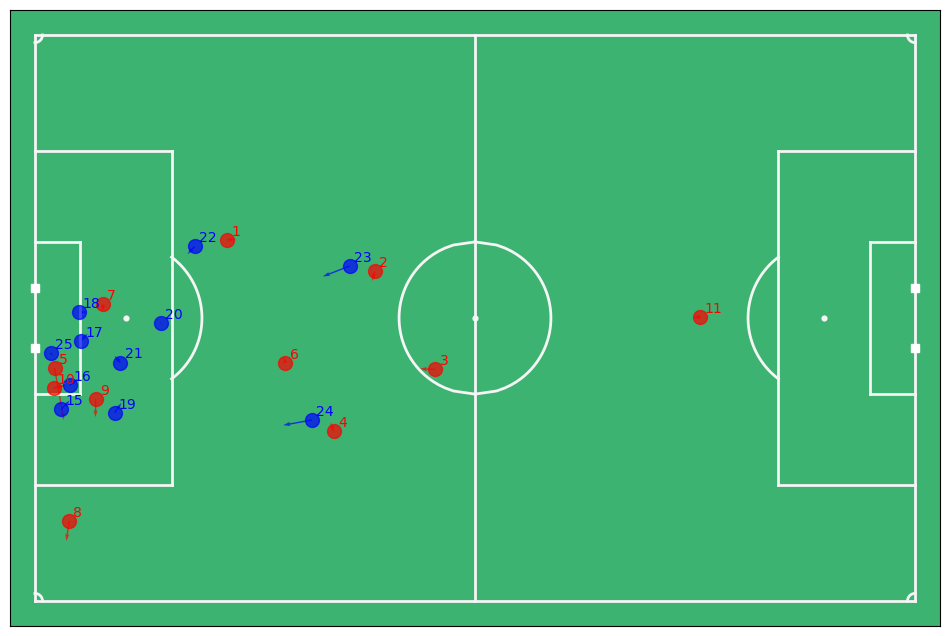

In [20]:
# plot a random frame, plotting the player velocities using quivers
mviz.plot_frame(
    tracking_home.loc[10000],
    tracking_away.loc[10000],
    include_player_velocities=True,
    annotate=True,
)

In [21]:
# Create a Physical summary dataframe for home players
home_players = np.unique(
    [c.split("_")[1] for c in tracking_home.columns if c[:4] == "Home"]
)
home_summary = pd.DataFrame(index=home_players)


In [23]:
# Calculate minutes played for each player
minutes = []
for player in home_players:
    # search for first and last frames that we have a position observation for each player (when a player is not on the pitch positions are NaN)
    column = "Home_" + player + "_x"  # use player x-position coordinate
    player_minutes = (
        (
            tracking_home[column].last_valid_index()
            - tracking_home[column].first_valid_index()
            + 1
        )
        / 25
        / 60.0
    )  # convert to minutes
    minutes.append(player_minutes)
home_summary["Minutes Played"] = minutes
home_summary = home_summary.sort_values(["Minutes Played"], ascending=False)


In [25]:
# Calculate total distance covered for each player
distance = []
for player in home_summary.index:
    column = "Home_" + player + "_speed"
    player_distance = (
        tracking_home[column].sum() / 25.0 / 1000
    )  # this is the sum of the distance travelled from one observation to the next (1/25 = 40ms) in km.
    distance.append(player_distance)
home_summary["Distance [km]"] = distance


Text(0.5, 1.0, 'Distance covered for each Home player in the match')

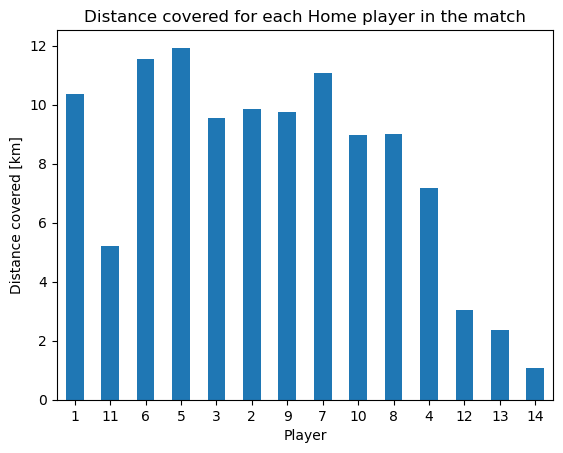

In [28]:
# make a simple bar chart of distance covered for each player
plt.subplots()
ax = home_summary["Distance [km]"].plot.bar(rot=0)
ax.set_xlabel("Player")
ax.set_ylabel("Distance covered [km]")
plt.title("Distance covered for each Home player in the match")

(<Figure size 1200x800 with 1 Axes>, <Axes: >)

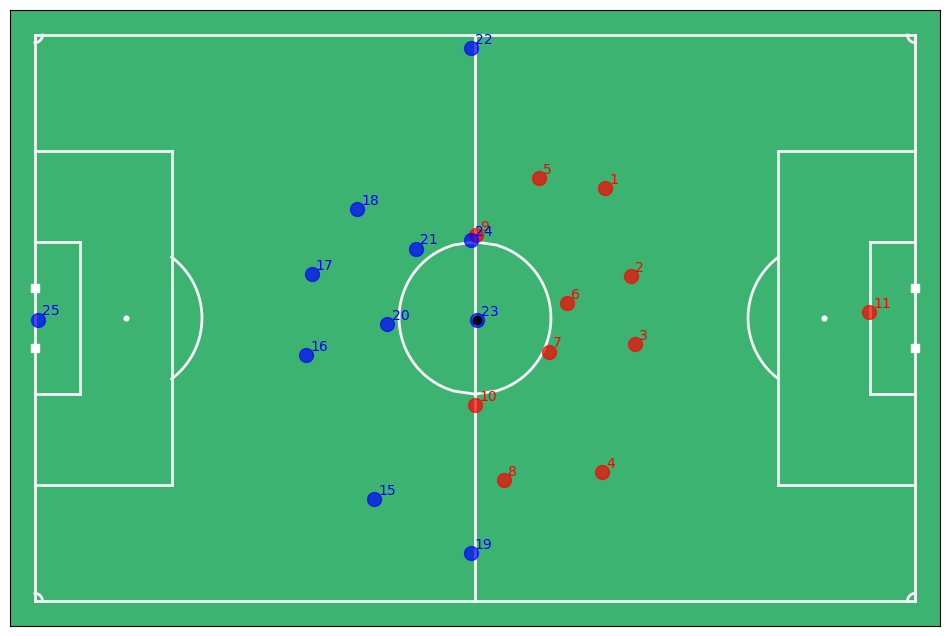

In [29]:
# plot positions at KO (to find out what position each player is playing)
mviz.plot_frame(
    tracking_home.loc[51],
    tracking_away.loc[51],
    include_player_velocities=False,
    annotate=True,
)


In [30]:
# now calculate distance covered while: walking, joggings, running, sprinting
walking = []
jogging = []
running = []
sprinting = []
for player in home_summary.index:
    column = "Home_" + player + "_speed"
    # walking (less than 2 m/s)
    player_distance = (
        tracking_home.loc[tracking_home[column] < 2, column].sum() / 25.0 / 1000
    )
    walking.append(player_distance)
    # jogging (between 2 and 4 m/s)
    player_distance = (
        tracking_home.loc[
            (tracking_home[column] >= 2) & (tracking_home[column] < 4), column
        ].sum()
        / 25.0
        / 1000
    )
    jogging.append(player_distance)
    # running (between 4 and 7 m/s)
    player_distance = (
        tracking_home.loc[
            (tracking_home[column] >= 4) & (tracking_home[column] < 7), column
        ].sum()
        / 25.0
        / 1000
    )
    running.append(player_distance)
    # sprinting (greater than 7 m/s)
    player_distance = (
        tracking_home.loc[tracking_home[column] >= 7, column].sum() / 25.0 / 1000
    )
    sprinting.append(player_distance)

home_summary["Walking [km]"] = walking
home_summary["Jogging [km]"] = jogging
home_summary["Running [km]"] = running
home_summary["Sprinting [km]"] = sprinting


Text(0, 0.5, 'Distance covered [km]')

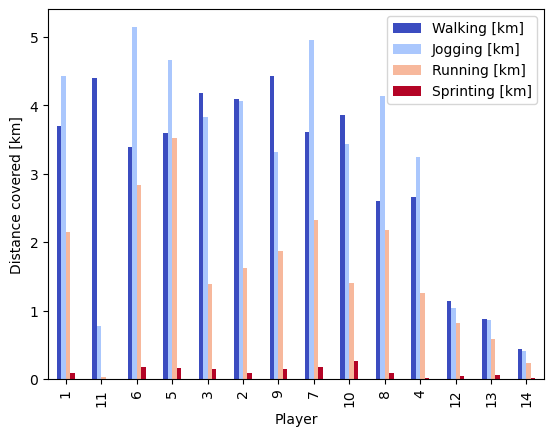

In [32]:
# make a clustered bar chart of distance covered for each player at each speed
ax = home_summary[
    ["Walking [km]", "Jogging [km]", "Running [km]", "Sprinting [km]"]
].plot.bar(colormap="coolwarm")
ax.set_xlabel("Player")
ax.set_ylabel("Distance covered [km]")


In [33]:
home_summary

,Minutes Played,Distance [km],Walking [km],Jogging [km],Running [km],Sprinting [km]
1,94.104000,10.374845,3.702603,4.437570,2.151669,0.083003
11,94.104000,5.205304,4.395623,0.778308,0.029655,0.001718
6,94.104000,11.541066,3.386647,5.147330,2.830999,0.176090
5,94.104000,11.933689,3.594323,4.660022,3.523475,0.155869
3,94.104000,9.551508,4.179233,3.833572,1.385873,0.152830
2,94.104000,9.857136,4.090812,4.068513,1.615984,0.081828
9,94.104000,9.769798,4.430251,3.324156,1.864238,0.151153
7,94.104000,11.080940,3.610617,4.959853,2.329719,0.180751
10,83.825333,8.969774,3.861562,3.434089,1.408055,0.266068
8,70.740667,9.019866,2.606854,4.135841,2.185446,0.091725


In [34]:
# sustained sprints: how many sustained sprints per match did each player complete? Defined as maintaining a speed > 7 m/s for at least 1 second
nsprints = []
sprint_threshold = 7  # minimum speed to be defined as a sprint (m/s)
sprint_window = (
    1 * 25
)  # minimum duration sprint should be sustained (in this case, 1 second = 25 consecutive frames)
for player in home_summary.index:
    column = "Home_" + player + "_speed"
    # trick here is to convolve speed with a window of size 'sprint_window', and find number of occassions that sprint was sustained for at least one window length
    # diff helps us to identify when the window starts
    player_sprints = np.diff(
        1
        * (
            np.convolve(
                1 * (tracking_home[column] >= sprint_threshold),
                np.ones(sprint_window),
                mode="same",
            )
            >= sprint_window
        )
    )
    nsprints.append(np.sum(player_sprints == 1))
home_summary["# sprints"] = nsprints


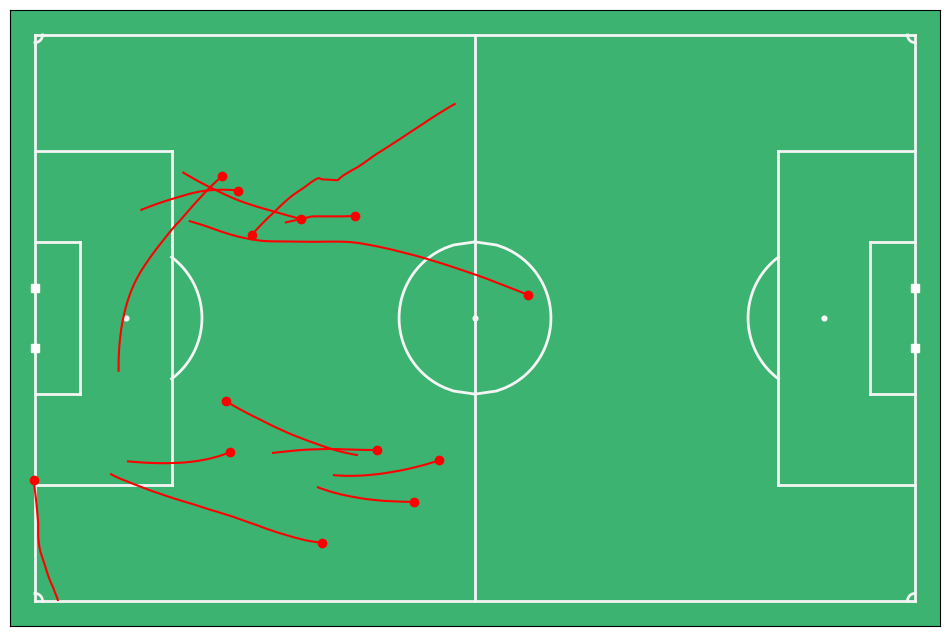

In [36]:
# Plot the trajectories for each of player 10's sprints
player = "10"
column = "Home_" + player + "_speed"  # spped
column_x = "Home_" + player + "_x"  # x position
column_y = "Home_" + player + "_y"  # y position
# same trick as before to find start and end indices of windows of size 'sprint_window' in which player speed was above the sprint_threshold
player_sprints = np.diff(
    1
    * (
        np.convolve(
            1 * (tracking_home[column] >= sprint_threshold),
            np.ones(sprint_window),
            mode="same",
        )
        >= sprint_window
    )
)
player_sprints_start = (
    np.where(player_sprints == 1)[0] - int(sprint_window / 2) + 1
)  # adding sprint_window/2 because of the way that the convolution is centred
player_sprints_end = np.where(player_sprints == -1)[0] + int(sprint_window / 2) + 1
# now plot all the sprints
fig, ax = mviz.plot_pitch()
for s, e in zip(player_sprints_start, player_sprints_end):
    ax.plot(tracking_home[column_x].iloc[s], tracking_home[column_y].iloc[s], "ro")
    ax.plot(
        tracking_home[column_x].iloc[s : e + 1],
        tracking_home[column_y].iloc[s : e + 1],
        "r",
    )


In [37]:
tracking_home

,Period,Time [s],Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,...,Home_6_speed,Home_7_vx,Home_7_vy,Home_7_speed,Home_8_vx,Home_8_vy,Home_8_speed,Home_9_vx,Home_9_vy,Home_9_speed
Frame,,,,,,,,,,,,,,,,,,,,,
1,1,0.04,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1,0.08,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1,0.12,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1,0.16,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,1,0.20,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,-0.143857,-1.323571,1.331366,-0.136286,-0.976286,0.985752,-0.174143,-1.493571,1.503689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2,5646.08,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,1.271789,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.378000,1.296857,1.892280
141153,2,5646.12,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,1.050501,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.544571,0.981143,1.829848
141154,2,5646.16,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,0.913685,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.533214,0.979929,1.819617


In [79]:
events[(events["Subtype"] == "ON TARGET-GOAL")]


,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
198,Home,SHOT,ON TARGET-GOAL,1,12202,488.08,12212,488.48,Player10,NaN,-47.70,-3.40,-54.06,-2.04
823,Away,SHOT,ON TARGET-GOAL,1,53049,2121.96,53075,2123.00,Player24,NaN,44.52,2.72,54.06,1.36
1671,Away,SHOT,ON TARGET-GOAL,2,115009,4600.36,115024,4600.96,Player20,NaN,40.28,1.36,55.12,2.72
1723,Home,SHOT,ON TARGET-GOAL,2,121027,4841.08,121055,4842.20,Player12,NaN,-30.74,5.44,-54.06,2.72


In [39]:
events["Type"].unique()

array(['SET PIECE', 'PASS', 'BALL LOST', 'CHALLENGE', 'RECOVERY',
       'BALL OUT', 'SHOT', 'FAULT RECEIVED', 'CARD'], dtype=object)

In [40]:
events["Subtype"].unique()

array(['KICK OFF', nan, 'INTERCEPTION', 'GROUND-LOST', 'GROUND-WON',
       'THROW IN', 'AERIAL-WON', 'HEAD-INTERCEPTION', 'AERIAL-LOST',
       'HEAD', 'OFF TARGET-OUT', 'TACKLE-LOST', 'AERIAL-FAULT-WON',
       'AERIAL-FAULT-LOST', 'FREE KICK', 'TACKLE-WON', 'CORNER KICK',
       'THEFT', 'CROSS', 'ON TARGET-GOAL', 'ON TARGET-SAVED', 'SAVED',
       'BLOCKED', 'DEEP BALL', 'GROUND-FAULT-LOST', 'GROUND-FAULT-WON',
       'GROUND-ADVANTAGE-LOST', 'GROUND-ADVANTAGE-WON',
       'HEAD-OFF TARGET-OUT', 'GOAL KICK-INTERCEPTION',
       'TACKLE-FAULT-LOST', 'OFFSIDE', 'TACKLE-FAULT-WON', 'YELLOW',
       'CLEARANCE', 'GOAL KICK', 'TACKLE-ADVANTAGE-WON',
       'CROSS-INTERCEPTION', 'GROUND', 'FORCED', 'FAULT-WON',
       'OFF TARGET-HEAD-OUT', 'FORCED-END HALF', 'KICK OFF-RETAKEN',
       'HEAD-ON TARGET-GOAL', 'HEAD-INTERCEPTION-CLEARANCE',
       'TACKLE-ADVANTAGE-LOST', 'HEAD-CLEARANCE', 'FREE KICK-RETAKEN',
       'HAND BALL', 'PENALTY', 'DRIBBLE-WON', 'CLEARANCE-INTERCEPTION'],
      d

In [43]:
tracking_home

,Period,Time [s],Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,...,Home_6_speed,Home_7_vx,Home_7_vy,Home_7_speed,Home_8_vx,Home_8_vy,Home_8_speed,Home_9_vx,Home_9_vy,Home_9_speed
Frame,,,,,,,,,,,,,,,,,,,,,
1,1,0.04,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1,0.08,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1,0.12,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1,0.16,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,1,0.20,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,-0.143857,-1.323571,1.331366,-0.136286,-0.976286,0.985752,-0.174143,-1.493571,1.503689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2,5646.08,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,1.271789,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.378000,1.296857,1.892280
141153,2,5646.12,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,1.050501,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.544571,0.981143,1.829848
141154,2,5646.16,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,0.913685,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.533214,0.979929,1.819617


In [44]:
events

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,51,2.04,51,2.04,Player23,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,51,2.04,87,3.48,Player23,Player20,0.00,-0.00,-10.60,-0.68
2,Away,PASS,NaN,1,146,5.84,186,7.44,Player20,Player18,-7.42,-0.00,-6.36,19.04
3,Away,PASS,NaN,1,248,9.92,283,11.32,Player18,Player17,-3.18,21.08,-20.14,14.96
4,Away,PASS,NaN,1,316,12.64,346,13.84,Player17,Player16,-22.26,12.24,-25.44,-5.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,Away,BALL LOST,INTERCEPTION,2,140122,5604.88,140183,5607.32,Player21,NaN,-4.24,18.36,22.26,-17.68
1931,Home,CHALLENGE,AERIAL-LOST,2,140180,5607.20,140180,5607.20,Player1,NaN,20.14,-13.60,NaN,NaN
1932,Away,CHALLENGE,AERIAL-LOST,2,140183,5607.32,140183,5607.32,Player24,NaN,19.08,-13.60,NaN,NaN
1933,Home,RECOVERY,NaN,2,140211,5608.44,140211,5608.44,Player12,NaN,16.96,-12.24,NaN,NaN


In [45]:
# Player 10 columns
player_id = "10"
column_x = f"Home_{player_id}_x"
column_y = f"Home_{player_id}_y"
column_speed = f"Home_{player_id}_speed"


In [52]:
# Basic Player Information
minutes_played = (
    (
        tracking_home[column_x].last_valid_index()
        - tracking_home[column_x].first_valid_index()
        + 1
    )
    / 25
    / 60
)
total_distance = tracking_home[column_speed].sum() / 25 / 1000
average_speed = tracking_home[column_speed].mean()
top_speed = tracking_home[column_speed].max()

# convert to km/h
average_speed = average_speed * 60 * 60 / 1000
top_speed = top_speed * 60 * 60 / 1000


In [53]:
print(f"Player 10 - Basic Information:")
print(f"Minutes Played: {minutes_played:.2f}")
print(f"Total Distance Covered: {total_distance:.2f} km")
print(f"Average Speed: {average_speed:.2f} km/h")
print(f"Top Speed: {top_speed:.2f} km/h")


Player 10 - Basic Information:
Minutes Played: 83.83
Total Distance Covered: 8.97 km
Average Speed: 5.72 km/h
Top Speed: 37.04 km/h


In [54]:
# Speed and Distance Analysis
walking_distance = (
    tracking_home.loc[tracking_home[column_speed] < 2, column_speed].sum() / 25 / 1000
)
jogging_distance = (
    tracking_home.loc[
        (tracking_home[column_speed] >= 2) & (tracking_home[column_speed] < 4),
        column_speed,
    ].sum()
    / 25
    / 1000
)
running_distance = (
    tracking_home.loc[
        (tracking_home[column_speed] >= 4) & (tracking_home[column_speed] < 7),
        column_speed,
    ].sum()
    / 25
    / 1000
)
sprinting_distance = (
    tracking_home.loc[tracking_home[column_speed] >= 7, column_speed].sum() / 25 / 1000
)


In [55]:
print("\nSpeed and Distance Analysis:")
print(f"Walking Distance: {walking_distance:.2f} km")
print(f"Jogging Distance: {jogging_distance:.2f} km")
print(f"Running Distance: {running_distance:.2f} km")
print(f"Sprinting Distance: {sprinting_distance:.2f} km")



Speed and Distance Analysis:
Walking Distance: 3.86 km
Jogging Distance: 3.43 km
Running Distance: 1.41 km
Sprinting Distance: 0.27 km


In [60]:
# Sustained Sprints Calculation
sprint_threshold = 7
sprint_window = 25
player_sprints = np.diff(
    1
    * (
        np.convolve(
            1 * (tracking_home[column_speed] >= sprint_threshold),
            np.ones(sprint_window),
            mode="same",
        )
        >= sprint_window
    )
)
sustained_sprints = np.sum(player_sprints == 1)

print(f"Sustained Sprints: {sustained_sprints}")

# Event Analysis
player_events = events[
    (events["From"] == f"Player{player_id}") | (events["To"] == f"Player{player_id}")
]

print("\nEvent Analysis:")
print(player_events["Type"].value_counts())
sustained_sprints = np.sum(player_sprints == 1)

print(f"Sustained Sprints: {sustained_sprints}")

# Event Analysis
player_events = events[
    (events["From"] == f"Player{player_id}") | (events["To"] == f"Player{player_id}")
]

print("\nEvent Analysis:")
print(player_events["Type"].value_counts())

pass_events = player_events[player_events["Type"] == "PASS"]


Sustained Sprints: 13

Event Analysis:
Type
PASS              35
CHALLENGE         23
BALL LOST         12
RECOVERY           7
SHOT               3
CARD               1
FAULT RECEIVED     1
BALL OUT           1
Name: count, dtype: int64
Sustained Sprints: 13

Event Analysis:
Type
PASS              35
CHALLENGE         23
BALL LOST         12
RECOVERY           7
SHOT               3
CARD               1
FAULT RECEIVED     1
BALL OUT           1
Name: count, dtype: int64


In [62]:
# Pass Success Rate
successful_passes = pass_events[
    ~pass_events["Subtype"].str.contains("INTERCEPTION", na=False)
]
pass_success_rate = len(successful_passes) / len(pass_events) * 100
print(f"\nPass Success Rate: {pass_success_rate:.2f}%")



Pass Success Rate: 100.00%


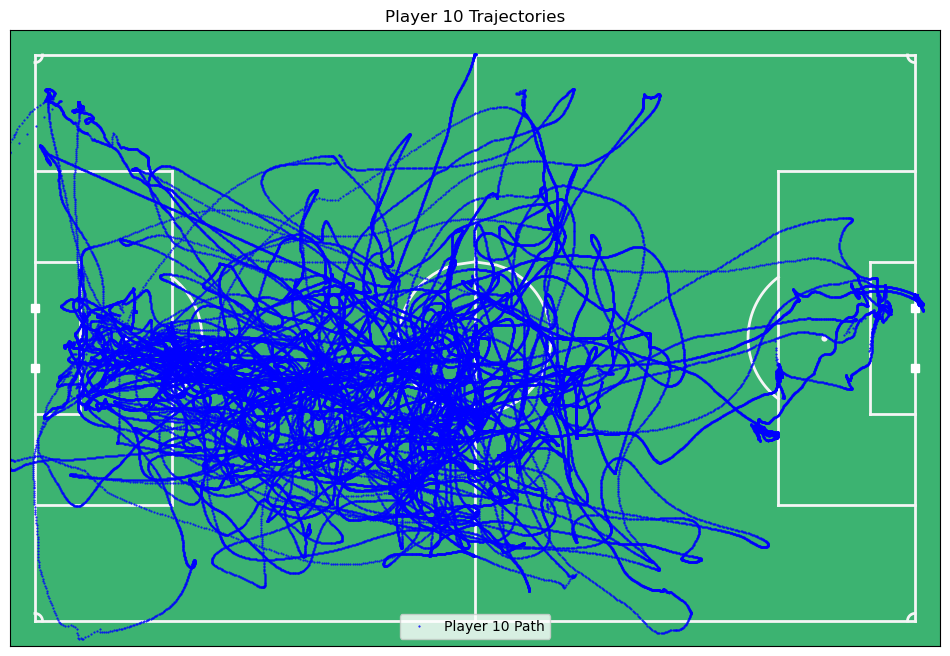

In [66]:
# Visualization: Player Trajectories (using Metrica_Viz)
fig, ax = mviz.plot_pitch()
ax.plot(
    tracking_home[column_x],
    tracking_home[column_y],
    "b.",
    markersize=1,
    label="Player 10 Path",
)
plt.title("Player 10 Trajectories")
plt.legend()
plt.show()


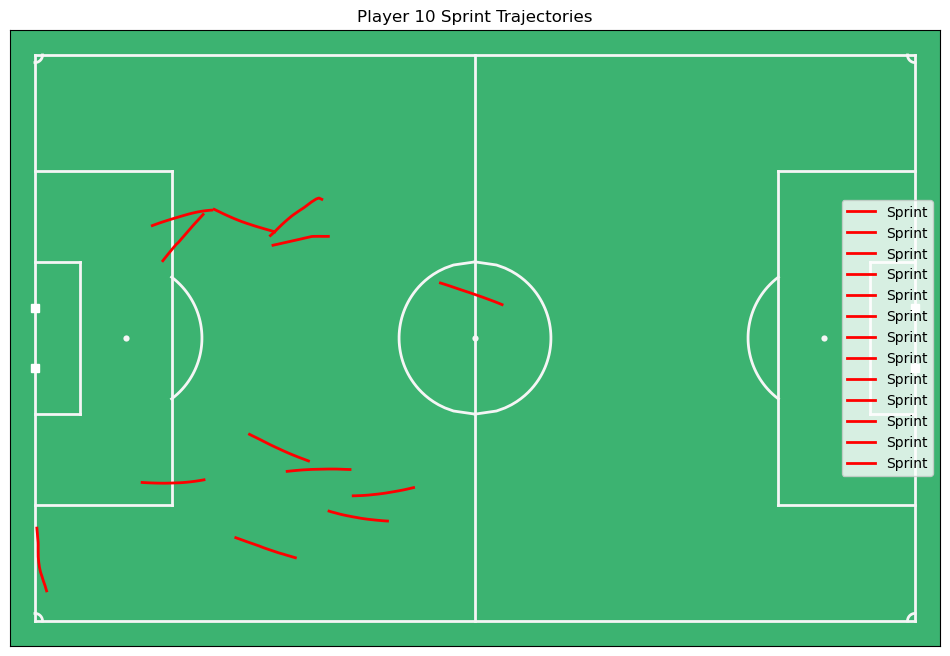

In [68]:
# Visualization: Sprint Trajectories
fig, ax = mviz.plot_pitch()
sprint_indices = np.where(player_sprints == 1)[0]
for s in sprint_indices:
    ax.plot(
        tracking_home[column_x].iloc[s : s + sprint_window],
        tracking_home[column_y].iloc[s : s + sprint_window],
        "r-",
        linewidth=2,
        label="Sprint",
    )
plt.title("Player 10 Sprint Trajectories")
plt.legend()
plt.show()


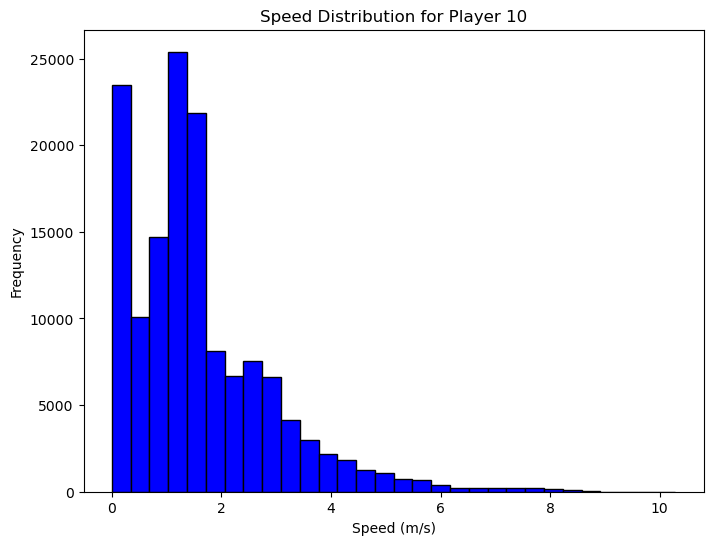

In [69]:
# Visualization: Speed Distribution
plt.figure(figsize=(8, 6))
plt.title("Speed Distribution for Player 10")
plt.hist(tracking_home[column_speed], bins=30, color="blue", edgecolor="black")
plt.xlabel("Speed (m/s)")
plt.ylabel("Frequency")
plt.show()


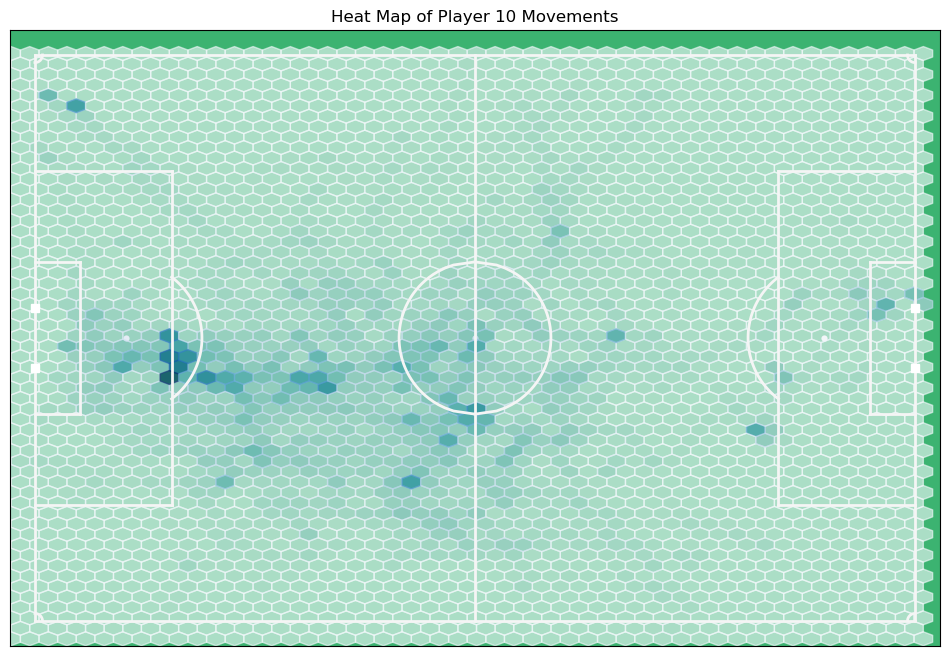

In [ ]:
# Visualization: Heat Map of Movements (Using Metrica Pitch Plot)
fig, ax = mviz.plot_pitch()
ax.hexbin(tracking_home[column_x], tracking_home[column_y], gridsize=50, cmap="Blues", alpha=0.6) alpha=0.6) alpha=0.6) alpha=0.6)
    tracking_home[column_x],
    tracking_home[column_y],
    gridsize=50,
    cmap="Blues",
    alpha=0.6,
)
plt.title("Heat Map of Player 10 Movements")
plt.show()


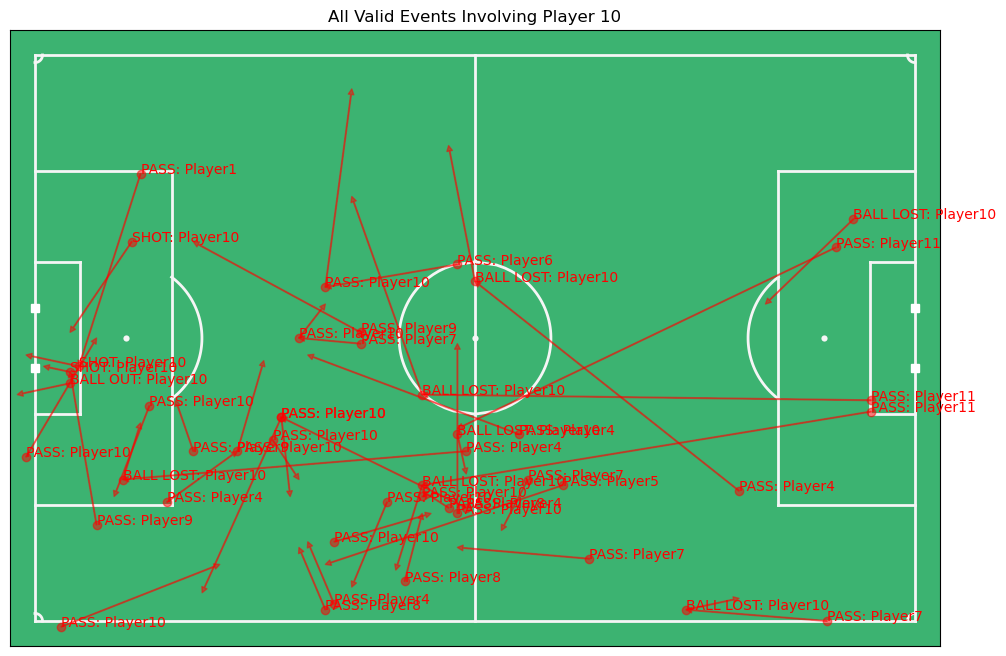

In [76]:
# Filter out events with missing coordinates before plotting
valid_player_events = player_events.dropna(
    subset=["Start X", "Start Y", "End X", "End Y"]
)

# Plotting All Valid Events Involving Player 10

fig, ax = mviz.plot_pitch()
mviz.plot_events(
    valid_player_events, figax=(fig, ax), indicators=["Marker", "Arrow"], annotate=True
)
plt.title("All Valid Events Involving Player 10")
plt.show()
